# Phase 1: D-FINE on VisDrone-DET (Standard Inference) - KAGGLE VERSION
This notebook provides the complete procedure for Phase 1 (Without SAHI) training and evaluating the D-FINE model on the VisDrone-DET dataset in COCO format using Kaggle.

## 1. Environment Setup

In [1]:
%cd /kaggle/working
!rm -rf D-FINE
!git clone https://github.com/Peterande/D-FINE.git
%cd /kaggle/working/D-FINE
!pip install -r requirements.txt

/kaggle/working
Cloning into 'D-FINE'...
remote: Enumerating objects: 1401, done.
remote: Counting objects: 100% (901/901), done.
remote: Compressing objects: 100% (337/337), done.
remote: Total 1401 (delta 745), reused 564 (delta 564), pack-reused 500 (from 2)
Receiving objects: 100% (1401/1401), 460.76 KiB | 10.47 MiB/s, done.
Resolving deltas: 100% (903/903), done.
/kaggle/working/D-FINE
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.1 MB/s eta 0:00:00


## 2. Dataset Preparation
In Kaggle, datasets you upload are stored in `/kaggle/input/`. We will create a symlink to it.

In [2]:
import os

print("Available datasets in Kaggle input:")
print(os.listdir('/kaggle/input'))

# !!! IMPORTANT !!!
# Change 'visdrone-coco' to the EXACT name of the folder inside /kaggle/input/ 
# that matches your uploaded dataset.
DATASET_PATH = '/kaggle/input/datasets/mdkhademulislamnahin/visdrone-coco-format/visdrone-coco'

# Create a symlink to the Kaggle input folder so D-FINE can access it easily
!ln -s {DATASET_PATH} /kaggle/working/D-FINE/dataset

Available datasets in Kaggle input:
['datasets']


## 3. Configuration
We use the built-in custom dataset configuration approach by overriding `custom_detection.yml`.

In [3]:
%%writefile /kaggle/working/D-FINE/configs/dataset/custom_detection.yml
task: detection

evaluator:
  type: CocoEvaluator
  iou_types: ['bbox']

num_classes: 10
remap_mscoco_category: true

train_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: dataset/images/train
    ann_file: dataset/coco_annotations/instances_train.json
    return_masks: false
    transforms:
      type: Compose
      ops:
        - {type: RandomPhotometricDistort, p: 0.5}
        - {type: RandomZoomOut, fill: 0}
        - {type: RandomIoUCrop, p: 0.8}
        - {type: SanitizeBoundingBox, min_size: 1}
        - {type: RandomHorizontalFlip}
        - {type: Resize, size: [640, 640]}
        - {type: SanitizeBoundingBox, min_size: 1}
        - {type: ConvertPILImage, dtype: 'float32', scale: true}
        - {type: ConvertBoundingBox, format: 'cxcywh', normalize: true}
  shuffle: true
  num_workers: 4
  drop_last: true
  collate_fn:
    type: BatchImageCollateFunction

val_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: dataset/images/val
    ann_file: dataset/coco_annotations/instances_val.json
    return_masks: false
    transforms:
      type: Compose
      ops:
        - {type: Resize, size: [640, 640]}
        - {type: ConvertPILImage, dtype: 'float32', scale: true}
  shuffle: false
  num_workers: 4
  drop_last: false
  collate_fn:
    type: BatchImageCollateFunction


Overwriting /kaggle/working/D-FINE/configs/dataset/custom_detection.yml


## 4. Training (Phase 1)
Train the model for 50 epochs with 640x640 resolution.
We use the `-u` argument to strictly force the batch size to 8 (training) and 16 (validation) to prevent Kaggle GPU Out-Of-Memory errors.

In [4]:
import os, shutil
# ── Configuration ─────────────────────────────────────────────────────────────
OUTPUT_DIR           = '/kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom'
BACKUP_DIR           = '/kaggle/working/checkpoints'   # backed up to session output
# If you saved a previous checkpoint as a Kaggle dataset, put its path here.
# e.g. if your dataset is named "dfine-checkpoints", set:
KAGGLE_INPUT_CKPT_DIR = '/kaggle/input/dfine-checkpoints'   # <── change if needed
LAST_CKPT = os.path.join(OUTPUT_DIR, 'last.pth')
BEST_CKPT = os.path.join(OUTPUT_DIR, 'best_stg1.pth')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(BACKUP_DIR, exist_ok=True)
# ── Checkpoint restore helper ─────────────────────────────────────────────────
def restore_checkpoint(src_dir, label):
    """Copy last.pth and best_stg1.pth from src_dir to OUTPUT_DIR (if missing)."""
    restored = False
    for fname, dst in [('last.pth', LAST_CKPT), ('best_stg1.pth', BEST_CKPT)]:
        src = os.path.join(src_dir, fname)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy2(src, dst)
            size_mb = os.path.getsize(dst) / 1024 / 1024
            print(f'[Checkpoint] Restored {fname} from {label}  ({size_mb:.1f} MB)')
            restored = True
    return restored
# ── Determine checkpoint to resume from ──────────────────────────────────────
if os.path.exists(LAST_CKPT):
    print(f'[Checkpoint] Found checkpoint in output dir: {LAST_CKPT}')
elif restore_checkpoint(BACKUP_DIR, 'session backup'):
    pass
elif restore_checkpoint(KAGGLE_INPUT_CKPT_DIR, 'Kaggle input dataset'):
    pass
else:
    print('[Checkpoint] No checkpoint found – training will start from scratch.')
# ── Build and run training command ───────────────────────────────────────────
%cd /kaggle/working/D-FINE
resume_flag = f'-r {LAST_CKPT}' if os.path.exists(LAST_CKPT) else ''
if resume_flag:
    print(f'[Checkpoint] ▶ Resuming training from: {LAST_CKPT}')
else:
    print('[Checkpoint] ▶ Starting fresh training run.')
# checkpoint_freq=1 saves last.pth every epoch (safest for Kaggle GPU time limits)
cmd = (
    f'python train.py '
    f'-c configs/dfine/custom/dfine_hgnetv2_n_custom.yml '
    f'--use-amp --seed 42 '
    f'{resume_flag} '
    f'-u epochs=50 train_dataloader.total_batch_size=8 '
    f'val_dataloader.total_batch_size=16 checkpoint_freq=1'
)
print(f'[Command] Running: {cmd}\n')
os.system(cmd)

[Checkpoint] No checkpoint found – training will start from scratch.
/kaggle/working/D-FINE
[Checkpoint] ▶ Starting fresh training run.
[Command] Running: python train.py -c configs/dfine/custom/dfine_hgnetv2_n_custom.yml --use-amp --seed 42  -u epochs=50 train_dataloader.total_batch_size=8 val_dataloader.total_batch_size=16 checkpoint_freq=1



2026-06-09 14:44:07.774571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781016247.966361      64 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781016248.023382      64 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781016248.477141      64 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781016248.477192      64 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781016248.477195      64 computation_placer.cc:177] computation placer alr

Not init distributed mode.
cfg: 
{'_collate_fn': None,
 '_criterion': None,
 '_ema': None,
 '_evaluator': None,
 '_lr_scheduler': None,
 '_lr_warmup_scheduler': None,
 '_model': None,
 '_optimizer': None,
 '_postprocessor': None,
 '_scaler': None,
 '_train_batch_size': None,
 '_train_dataloader': None,
 '_train_dataset': None,
 '_train_shuffle': None,
 '_val_batch_size': None,
 '_val_dataloader': None,
 '_val_dataset': None,
 '_val_shuffle': None,
 '_writer': None,
 'batch_size': None,
 'checkpoint_freq': 1,
 'clip_max_norm': 0.1,
 'device': '',
 'ema_decay': 0.9999,
 'ema_warmups': 2000,
 'epochs': 50,
 'find_unused_parameters': False,
 'last_epoch': -1,
 'num_workers': 0,
 'output_dir': './output/dfine_hgnetv2_n_custom',
 'print_freq': 100,
 'resume': None,
 'seed': 42,
 'summary_dir': None,
 'sync_bn': True,
 'task': 'detection',
 'tuning': None,
 'use_amp': True,
 'use_ema': True,
 'yaml_cfg': {'DFINE': {'backbone': 'HGNetv2',
                        'decoder': 'DFINETransformer',


100%|██████████| 7.21M/7.21M [00:00<00:00, 83.6MB/s]
/kaggle/working/D-FINE/src/core/workspace.py:178: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return module(**module_kwargs)


Loaded stage1 B0 HGNetV2 from URL.
Loaded stage1 B0 HGNetV2 from URL.
Initial lr: [0.0004, 0.0004, 0.0008, 0.0008]
building train_dataloader with batch_size=8...
building val_dataloader with batch_size=16...

------------------------------------- Calculate Flops Results -------------------------------------
Notations:
number of parameters (Params), number of multiply-accumulate operations(MACs),
number of floating-point operations (FLOPs), floating-point operations per second (FLOPS),
fwd FLOPs (model forward propagation FLOPs), bwd FLOPs (model backward propagation FLOPs),
default model backpropagation takes 2.00 times as much computation as forward propagation.

Total Training Params:                                                  3.73 M  
fwd MACs:                                                               3.5301 GMACs
fwd FLOPs:                                                              7.1238 GFLOPS
fwd+bwd MACs:                                                           10.

/kaggle/working/D-FINE/src/solver/det_engine.py:125: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  if not math.isfinite(loss_value):


Epoch: [0/50]  [  0/808]  eta: 2:26:43  lr: 0.000002  loss: 29.2286 (29.2286)  loss_vfl: 0.1196 (0.1196)  loss_bbox: 0.8601 (0.8601)  loss_giou: 2.4335 (2.4335)  loss_fgl: 0.1703 (0.1703)  loss_vfl_aux_0: 0.1124 (0.1124)  loss_bbox_aux_0: 0.8601 (0.8601)  loss_giou_aux_0: 2.4335 (2.4335)  loss_fgl_aux_0: 0.1703 (0.1703)  loss_ddf_aux_0: 0.0000 (0.0000)  loss_vfl_aux_1: 0.1044 (0.1044)  loss_bbox_aux_1: 0.8601 (0.8601)  loss_giou_aux_1: 2.4335 (2.4335)  loss_fgl_aux_1: 0.1703 (0.1703)  loss_ddf_aux_1: 0.0000 (0.0000)  loss_vfl_pre: 0.1124 (0.1124)  loss_bbox_pre: 0.8601 (0.8601)  loss_giou_pre: 2.4335 (2.4335)  loss_vfl_enc_0: 0.1116 (0.1116)  loss_bbox_enc_0: 0.8601 (0.8601)  loss_giou_enc_0: 2.4335 (2.4335)  loss_vfl_dn_0: 0.7554 (0.7554)  loss_bbox_dn_0: 0.1631 (0.1631)  loss_giou_dn_0: 1.3767 (1.3767)  loss_fgl_dn_0: 0.8137 (0.8137)  loss_ddf_dn_0: 0.0000 (0.0000)  loss_vfl_dn_1: 0.7515 (0.7515)  loss_bbox_dn_1: 0.1631 (0.1631)  loss_giou_dn_1: 1.3767 (1.3767)  loss_fgl_dn_1: 0.8137

0

# **4b(Backup) After Training**

In [5]:
import os, shutil
OUTPUT_DIR = '/kaggle/working/D-FINE/output/dfine_hgnetv2_n_custom'
BACKUP_DIR = '/kaggle/working/checkpoints'
os.makedirs(BACKUP_DIR, exist_ok=True)
backed_up = []
for fname in ['last.pth', 'best_stg1.pth']:
    src = os.path.join(OUTPUT_DIR, fname)
    dst = os.path.join(BACKUP_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size_mb = os.path.getsize(dst) / 1024 / 1024
        print(f'[Backup] {fname}  →  {dst}  ({size_mb:.1f} MB)')
        backed_up.append(fname)
    else:
        print(f'[Backup] {fname} not found – skipping.')
# Also back up any epoch-numbered checkpoints
epoch_ckpts = sorted([
    f for f in os.listdir(OUTPUT_DIR)
    if f.startswith('checkpoint') and f.endswith('.pth')
])
for fname in epoch_ckpts:
    src = os.path.join(OUTPUT_DIR, fname)
    dst = os.path.join(BACKUP_DIR, fname)
    shutil.copy2(src, dst)
    size_mb = os.path.getsize(dst) / 1024 / 1024
    print(f'[Backup] {fname}  →  {dst}  ({size_mb:.1f} MB)')
    backed_up.append(fname)
if backed_up:
    print(f'\n✅  Backed up {len(backed_up)} checkpoint(s) to: {BACKUP_DIR}')
    print('   Step 1: Go to notebook "Output" tab → find the checkpoints/ folder')
    print('   Step 2: Save it as a Kaggle Dataset (e.g. "dfine-checkpoints")')
    print('   Step 3: In a new session, add that dataset as notebook input')
    print('   Step 4: Re-run the notebook → training will auto-resume ✔')
else:
    print('⚠️   No checkpoints found. Check OUTPUT_DIR path.')
    print(f'    Looking in: {OUTPUT_DIR}')
    if os.path.isdir(OUTPUT_DIR):
        print(f'    Contents: {os.listdir(OUTPUT_DIR)}')

[Backup] last.pth  →  /kaggle/working/checkpoints/last.pth  (58.0 MB)
[Backup] best_stg1.pth  →  /kaggle/working/checkpoints/best_stg1.pth  (58.1 MB)
[Backup] checkpoint0000.pth  →  /kaggle/working/checkpoints/checkpoint0000.pth  (58.1 MB)
[Backup] checkpoint0001.pth  →  /kaggle/working/checkpoints/checkpoint0001.pth  (58.1 MB)
[Backup] checkpoint0002.pth  →  /kaggle/working/checkpoints/checkpoint0002.pth  (58.1 MB)
[Backup] checkpoint0003.pth  →  /kaggle/working/checkpoints/checkpoint0003.pth  (58.1 MB)
[Backup] checkpoint0004.pth  →  /kaggle/working/checkpoints/checkpoint0004.pth  (58.1 MB)
[Backup] checkpoint0005.pth  →  /kaggle/working/checkpoints/checkpoint0005.pth  (58.1 MB)
[Backup] checkpoint0006.pth  →  /kaggle/working/checkpoints/checkpoint0006.pth  (58.1 MB)
[Backup] checkpoint0007.pth  →  /kaggle/working/checkpoints/checkpoint0007.pth  (58.1 MB)
[Backup] checkpoint0008.pth  →  /kaggle/working/checkpoints/checkpoint0008.pth  (58.1 MB)
[Backup] checkpoint0009.pth  →  /kaggle/

## 5. Evaluation
Evaluate the trained model on the `test-dev` split using the `--test-only` flag and the `-u` argument to override the val paths.

In [6]:
%cd /kaggle/working/D-FINE
!python train.py -c configs/dfine/custom/dfine_hgnetv2_n_custom.yml --test-only -r output/dfine_hgnetv2_n_custom/best_stg1.pth -u val_dataloader.dataset.img_folder=dataset/images/test-dev val_dataloader.dataset.ann_file=dataset/coco_annotations/instances_test-dev.json val_dataloader.total_batch_size=16

/kaggle/working/D-FINE
2026-06-09 23:14:56.792497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781046896.819954    1690 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781046896.828651    1690 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781046896.852403    1690 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781046896.852474    1690 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781046896.852484    1690 computation_placer.cc:177]

## 6. Inference
Run inference on a single test image using `torch_inf.py`.

/kaggle/working/D-FINE
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 MB 4.0 MB/s eta 0:00:00
  Created wheel for tensorrt: filename=tensorrt-11.0.0.114-py3-none-any.whl size=16564 sha256=cee102e86246b520dd0b20f06f6f1dca76852e44fe23cb6b0d12db04fbe2a63d
  Stored in directory: /root/.cache/pip/wheels/29/47/36/44f3f3efb5d611686bb450aaef0846148979711b42c7d076d2
  Created wheel for tensorrt_cu13: filename=tensorrt_cu13-11.0.0.114-py3

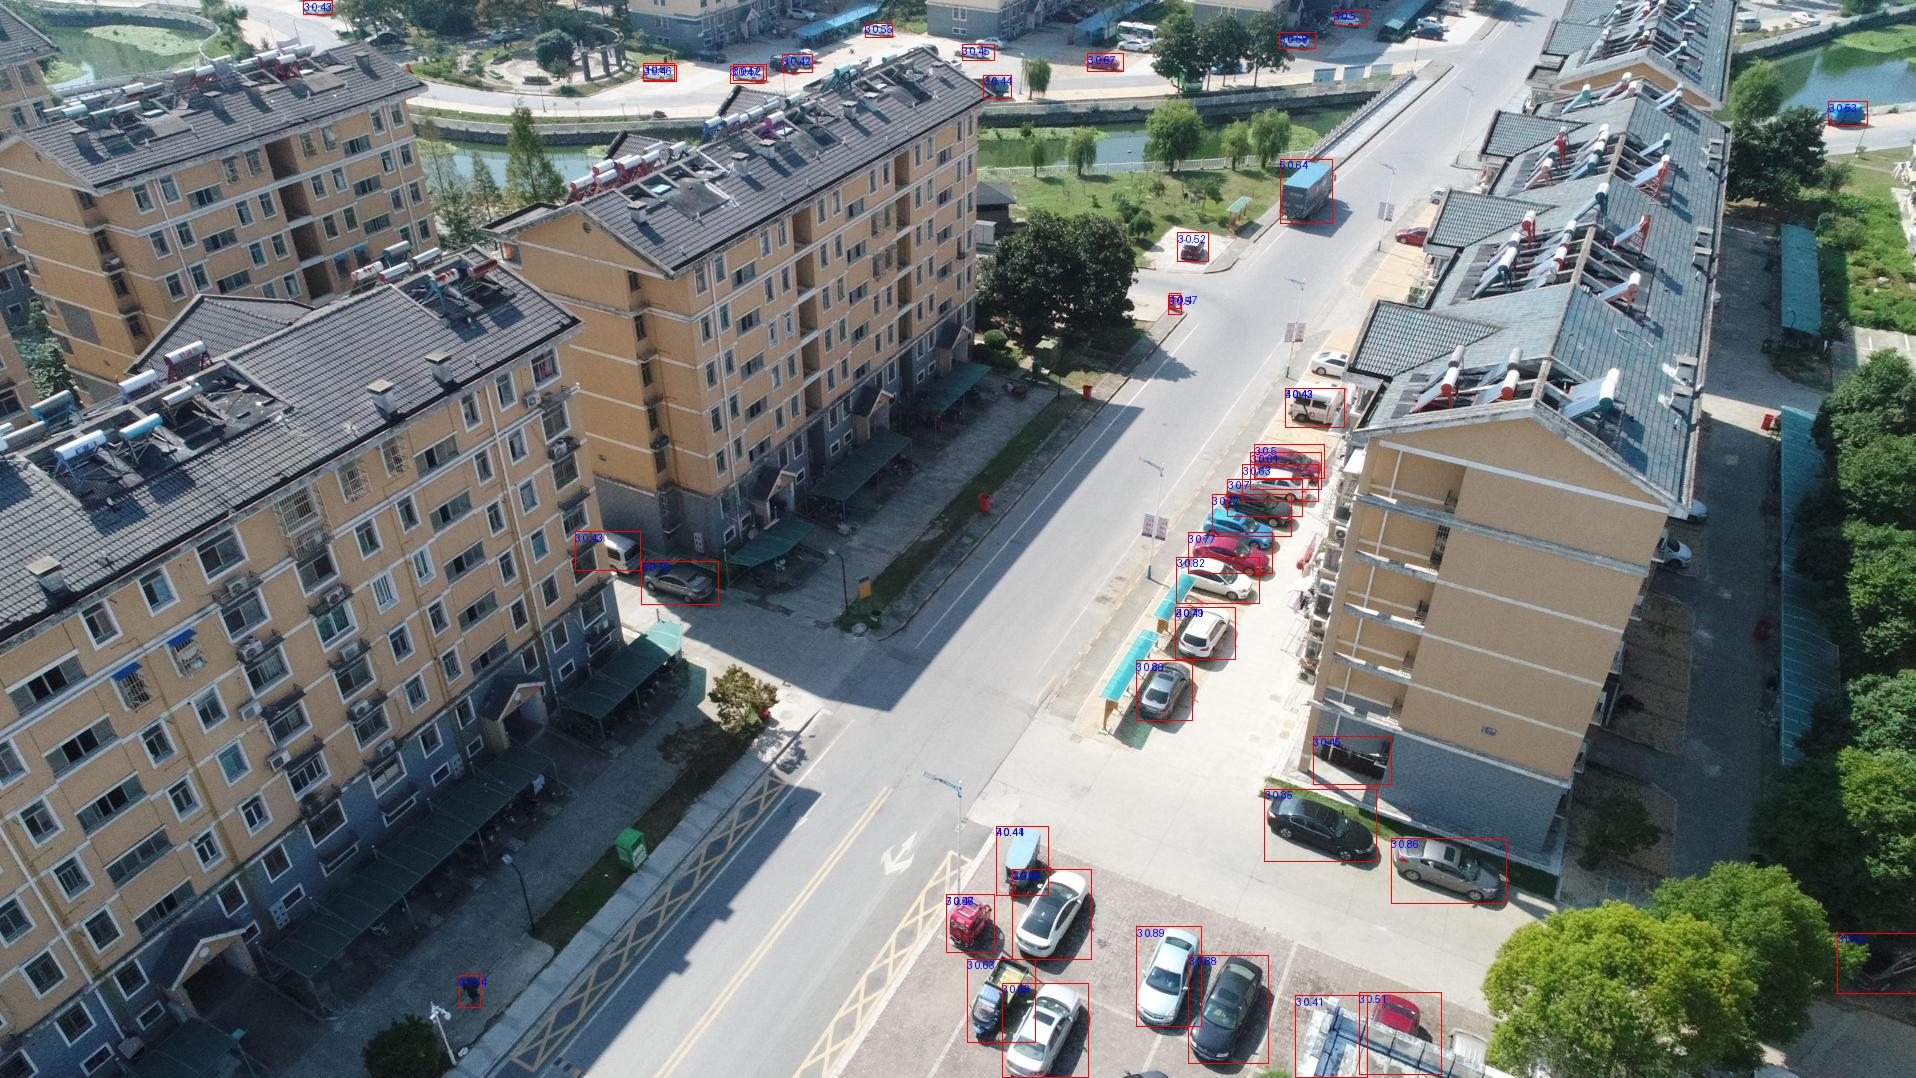

In [7]:
%cd /kaggle/working/D-FINE
!pip install -r tools/inference/requirements.txt
import os
test_images = os.listdir('dataset/images/test-dev')
sample_img = f'dataset/images/test-dev/{test_images[0]}'
print(f"Running inference on {sample_img}")
!python tools/inference/torch_inf.py -c configs/dfine/custom/dfine_hgnetv2_n_custom.yml -r output/dfine_hgnetv2_n_custom/best_stg1.pth --input $sample_img --device cuda:0
from IPython.display import Image
Image('torch_results.jpg')